In [1]:
from preprocessing import get_data, get_encoded_data, split_data

features, target = get_data()
encoded_features, target = get_encoded_data(features, target)
X_train, X_valid, X_test, y_train, y_valid, y_test = split_data(encoded_features, target)

In [2]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

In [3]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42,
    n_estimators=1000,
    max_depth=40,
    min_samples_split=2,
    class_weight='balanced'
)
model.fit(X_train_over, y_train_over)
valid_pred = model.predict(X_valid)
valid_pred_proba = model.predict_proba(X_valid)[:, 1]

In [4]:

from sklearn.metrics import accuracy_score, f1_score, recall_score, average_precision_score, precision_score

accuracy = accuracy_score(y_valid, valid_pred)
f1 = f1_score(y_valid, valid_pred)
recall = recall_score(y_valid, valid_pred)
ap_score = average_precision_score(y_valid, valid_pred_proba)
precision = precision_score(y_valid, valid_pred)

print(f"Validation 성능 - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, AP Score: {ap_score:.4f}")

Validation 성능 - Accuracy: 0.8507, F1 Score: 0.5770, Recall: 0.4948, Precision: 0.6920, AP Score: 0.6417


/Users/tera/Desktop/workspace/skn_21/project/project_02/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


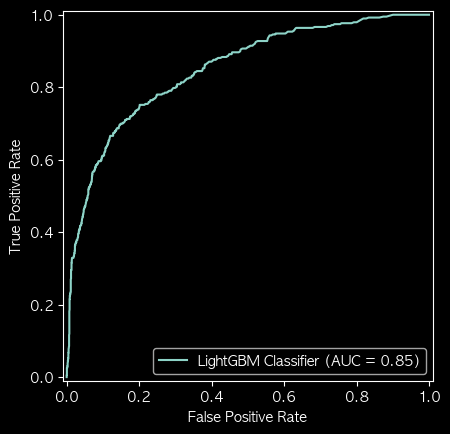

In [5]:
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score

rfc_roc = roc_auc_score(y_valid, valid_pred_proba)
fpr, recall, thresh = roc_curve(y_valid, valid_pred_proba)
disp_roc_rfc = RocCurveDisplay(
    fpr=fpr, tpr=recall,
    roc_auc=rfc_roc,
    estimator_name='LightGBM Classifier'
)
disp_roc_rfc.plot()
    